In [2]:
import pandas as pd
import matplotlib.pylab as plt
import networkx as nx
import re
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
# mac의 경우 matplotlib 한글깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'

In [4]:
df = pd.read_csv("../data/twice_korean_singles_lines.csv")

In [5]:
# 가사 전처리
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_lyric'] = df['lyric'].fillna('').apply(clean_text)
df['vocal1'] = df['vocal1'].fillna('Unknown')

In [6]:
# 데이터를 Apriori 입력 형식으로 변환
transactions = []

for _, row in df.iterrows():
    words = row['clean_lyric'].split()

    # 빈 단어 제거
    words = [w for w in words if len(w) > 0]

    # 멤버 이름을 하나의 "항목"으로 추가
    words.append(f"VOCAL_{row['vocal1']}")

    transactions.append(words)

In [7]:
# 원 핫 인코딩
te = TransactionEncoder()
te_arrays = te.fit(transactions).transform(transactions)
df_tx = pd.DataFrame(te_arrays, columns=te.columns_)

In [8]:
# Apriori 적용
freq_items = apriori(df_tx, min_support=0.01, use_colnames=True)

print("📌 Frequent Itemsets (상위 10개) :")
print(freq_items.head(10))

📌 Frequent Itemsets (상위 10개) :
    support           itemsets
0  0.093633  (VOCAL_Chaeyoung)
1  0.091760     (VOCAL_Dahyun)
2  0.097378  (VOCAL_Jeongyeon)
3  0.172285      (VOCAL_Jihyo)
4  0.099251       (VOCAL_Mina)
5  0.088951       (VOCAL_Momo)
6  0.170412     (VOCAL_Nayeon)
7  0.088951       (VOCAL_Sana)
8  0.097378      (VOCAL_Tzuyu)
9  0.020599                (a)


In [9]:
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)

In [10]:
# 멤버로 향하는 규칙만 필터링
rules_to_vocal = rules[rules['consequents'].apply(lambda x: any('VOCAL_' in i for i in x))]

In [11]:
print("=== 규칙 전체 ===")
print(rules.head())

print("\n규칙 개수:", len(rules))

print("\n컬럼 목록:", rules.columns.tolist())


=== 규칙 전체 ===
      antecedents     consequents  antecedent support  consequent support  \
0           (you)  (VOCAL_Dahyun)            0.087079            0.091760   
1  (VOCAL_Dahyun)           (you)            0.091760            0.087079   
2   (VOCAL_Jihyo)          (baby)            0.172285            0.036517   
3          (baby)   (VOCAL_Jihyo)            0.036517            0.172285   
4   (VOCAL_Jihyo)           (deo)            0.172285            0.038390   

   support  confidence      lift  representativity  leverage  conviction  \
0   0.0103    0.118280  1.289006               1.0  0.002309    1.030077   
1   0.0103    0.112245  1.289006               1.0  0.002309    1.028348   
2   0.0103    0.059783  1.637124               1.0  0.004008    1.024745   
3   0.0103    0.282051  1.637124               1.0  0.004008    1.152889   
4   0.0103    0.059783  1.557264               1.0  0.003686    1.022753   

   zhangs_metric   jaccard  certainty  kulczynski  
0       0.2455

In [15]:
print("\n 멤버 관련 규칙 TOP 5\n")
print(rules_to_vocal.sort_values(by="confidence", ascending=False).head())


 멤버 관련 규칙 TOP 5

   antecedents     consequents  antecedent support  consequent support  \
11       (nal)   (VOCAL_Jihyo)            0.032772            0.172285   
3       (baby)   (VOCAL_Jihyo)            0.036517            0.172285   
14         (i)  (VOCAL_Nayeon)            0.074906            0.170412   
5        (deo)   (VOCAL_Jihyo)            0.038390            0.172285   
8         (me)   (VOCAL_Jihyo)            0.065543            0.172285   

     support  confidence      lift  representativity  leverage  conviction  \
11  0.010300    0.314286  1.824224               1.0  0.004654    1.207085   
3   0.010300    0.282051  1.637124               1.0  0.004008    1.152889   
14  0.020599    0.275000  1.613736               1.0  0.007834    1.144259   
5   0.010300    0.268293  1.557264               1.0  0.003686    1.131211   
8   0.015918    0.242857  1.409627               1.0  0.004626    1.093209   

    zhangs_metric   jaccard  certainty  kulczynski  
11       0.4671

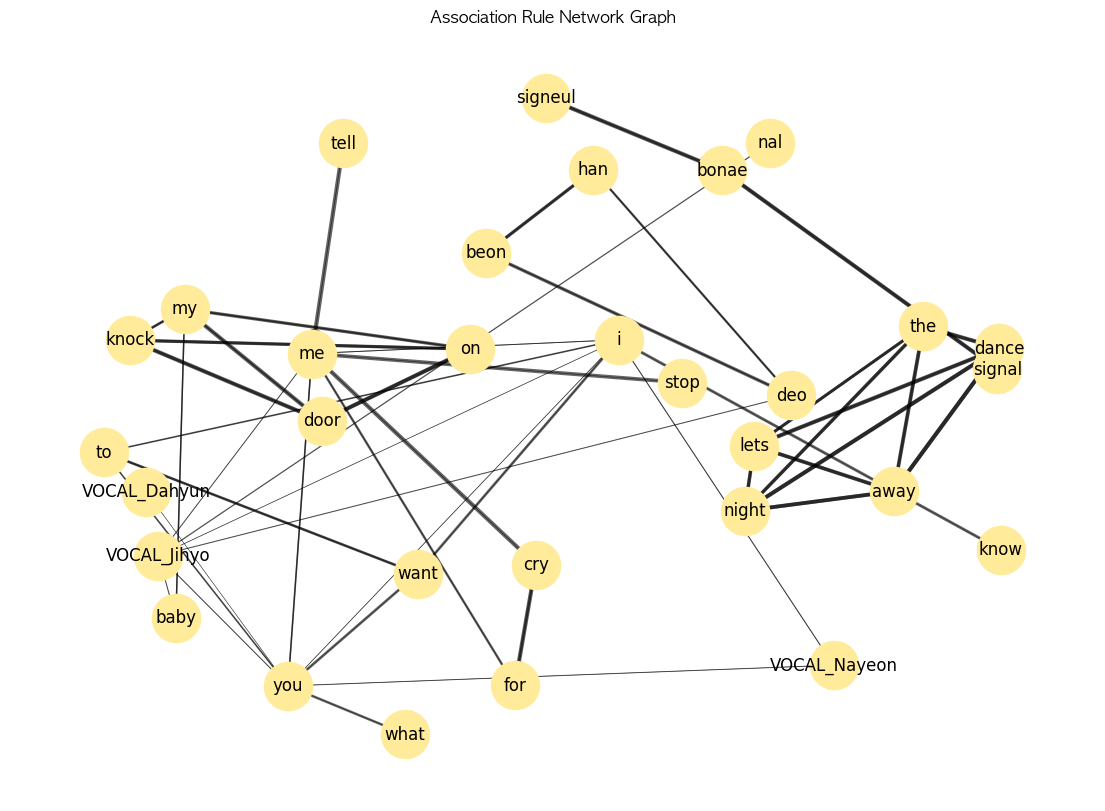

In [13]:

G = nx.DiGraph()

# 규칙들 기반으로 엣지 추가
for _, row in rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['confidence'])

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, k=1)

# 노드
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='#ffeb99')

# 엣지 (두껍게: confidence 높음)
edges = G.edges(data=True)
weights = [d['weight']*3 for (_,_,d) in edges]
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)

# 라벨
nx.draw_networkx_labels(G, pos, font_size=12)

plt.title("Association Rule Network Graph")
plt.axis('off')
plt.show()